In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/Master_data/Cleanning_and_preprosscing.csv")

In [4]:
df.shape

(482257, 41)

In [5]:
# check missing
df.isnull().sum()



shopNo               0
month                0
year                 0
noOfRcs              0
noOfTrans            0
riceAfsc             0
riceFsc              0
riceAap              0
wheat                0
sugar                0
totalAmount          0
otherShopTransCnt    0
riceAap_available    0
wheat_available      0
rcNfsaAay            0
unitsNfsaAay         0
rcNfsaPhh            0
unitsNfsaPhh         0
totalRcNfsa          0
totalUnitsNfsa       0
rcStateAay           0
unitsStateAay        0
rcStatePhh           0
unitsStatePhh        0
rcStateAap           0
unitsStateAap        0
totalRcState         0
totalUnitsState      0
totalRcs             0
totalUnits           0
units                0
gasCylinders         0
distCode             0
distName             0
officeCode           0
officeName           0
longitude            0
latitude             0
fpsStatus            0
fpsType              0
dateTime             0
dtype: int64

In [6]:
#Remove Duplicate Rows
df.drop_duplicates(inplace=True)

In [7]:
df.columns

Index(['shopNo', 'month', 'year', 'noOfRcs', 'noOfTrans', 'riceAfsc',
       'riceFsc', 'riceAap', 'wheat', 'sugar', 'totalAmount',
       'otherShopTransCnt', 'riceAap_available', 'wheat_available',
       'rcNfsaAay', 'unitsNfsaAay', 'rcNfsaPhh', 'unitsNfsaPhh', 'totalRcNfsa',
       'totalUnitsNfsa', 'rcStateAay', 'unitsStateAay', 'rcStatePhh',
       'unitsStatePhh', 'rcStateAap', 'unitsStateAap', 'totalRcState',
       'totalUnitsState', 'totalRcs', 'totalUnits', 'units', 'gasCylinders',
       'distCode', 'distName', 'officeCode', 'officeName', 'longitude',
       'latitude', 'fpsStatus', 'fpsType', 'dateTime'],
      dtype='object')

In [8]:
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(exclude=['number']).columns

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['shopNo', 'month', 'year', 'noOfRcs', 'noOfTrans', 'riceAfsc',
       'riceFsc', 'riceAap', 'wheat', 'sugar', 'totalAmount',
       'otherShopTransCnt', 'riceAap_available', 'wheat_available',
       'rcNfsaAay', 'unitsNfsaAay', 'rcNfsaPhh', 'unitsNfsaPhh', 'totalRcNfsa',
       'totalUnitsNfsa', 'rcStateAay', 'unitsStateAay', 'rcStatePhh',
       'unitsStatePhh', 'rcStateAap', 'unitsStateAap', 'totalRcState',
       'totalUnitsState', 'totalRcs', 'totalUnits', 'units', 'gasCylinders',
       'distCode', 'officeCode', 'longitude', 'latitude'],
      dtype='object')

Categorical Columns:
Index(['distName', 'officeName', 'fpsStatus', 'fpsType', 'dateTime'], dtype='object')


In [9]:
df['distName'].nunique()

33

In [10]:
remove_cols = [

    # NFSA breakdown
    'rcNfsaAay',
    'unitsNfsaAay',
    'rcNfsaPhh',
    'unitsNfsaPhh',
    'totalRcNfsa',
    'totalUnitsNfsa',

    # State breakdown
    'rcStateAay',
    'unitsStateAay',
    'rcStatePhh',
    'unitsStatePhh',
    'rcStateAap',
    'unitsStateAap',
    'totalRcState',
    'totalUnitsState',

    # Optional (only if weak feature)
    'gasCylinders'
]

In [11]:
df.drop(columns=remove_cols, inplace=True, errors='ignore')

print("Useless columns removed")

Useless columns removed


In [12]:
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(exclude=['number']).columns

print("Numerical columns:\n", num_cols)
print("\nCategorical columns:\n", cat_cols)

Numerical columns:
 Index(['shopNo', 'month', 'year', 'noOfRcs', 'noOfTrans', 'riceAfsc',
       'riceFsc', 'riceAap', 'wheat', 'sugar', 'totalAmount',
       'otherShopTransCnt', 'riceAap_available', 'wheat_available', 'totalRcs',
       'totalUnits', 'units', 'distCode', 'officeCode', 'longitude',
       'latitude'],
      dtype='object')

Categorical columns:
 Index(['distName', 'officeName', 'fpsStatus', 'fpsType', 'dateTime'], dtype='object')


In [14]:
feature_df = pd.DataFrame({
    "Feature": df.columns,
    "DataType": df.dtypes.values,
    "Category": ["Numerical" if x in num_cols else "Categorical" for x in df.columns]
})

feature_df

,Feature,DataType,Category
0,shopNo,int64,Numerical
1,month,int64,Numerical
2,year,int64,Numerical
3,noOfRcs,int64,Numerical
4,noOfTrans,int64,Numerical
5,riceAfsc,float64,Numerical
6,riceFsc,float64,Numerical
7,riceAap,float64,Numerical
8,wheat,float64,Numerical
9,sugar,float64,Numerical


In [15]:
feature_df.shape

(26, 3)

In [16]:
df.columns

Index(['shopNo', 'month', 'year', 'noOfRcs', 'noOfTrans', 'riceAfsc',
       'riceFsc', 'riceAap', 'wheat', 'sugar', 'totalAmount',
       'otherShopTransCnt', 'riceAap_available', 'wheat_available', 'totalRcs',
       'totalUnits', 'units', 'distCode', 'distName', 'officeCode',
       'officeName', 'longitude', 'latitude', 'fpsStatus', 'fpsType',
       'dateTime'],
      dtype='object')

In [18]:
df.shape

(482257, 26)

In [19]:
outlier_cols = [

    'noOfRcs',
    'noOfTrans',

    'riceAfsc',
    'riceFsc',
    #'riceAap',

    #'wheat',
    #'sugar',

    #'totalAmount',

    'otherShopTransCnt',

    'totalRcs',
    'totalUnits',

    #'units'
]

In [20]:
for col in outlier_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outlier_count = df[
        (df[col] < lower_limit) |
        (df[col] > upper_limit)
    ].shape[0]

    total_rows = df.shape[0]

    percentage = (outlier_count / total_rows) * 100

    print(f"\nColumn: {col}")
    print(f"Outliers: {outlier_count}")
    print(f"Percentage: {percentage:.2f}%")


Column: noOfRcs
Outliers: 25219
Percentage: 5.23%

Column: noOfTrans
Outliers: 25388
Percentage: 5.26%

Column: riceAfsc
Outliers: 26647
Percentage: 5.53%

Column: riceFsc
Outliers: 31085
Percentage: 6.45%

Column: otherShopTransCnt
Outliers: 45616
Percentage: 9.46%

Column: totalRcs
Outliers: 20807
Percentage: 4.31%

Column: totalUnits
Outliers: 25609
Percentage: 5.31%


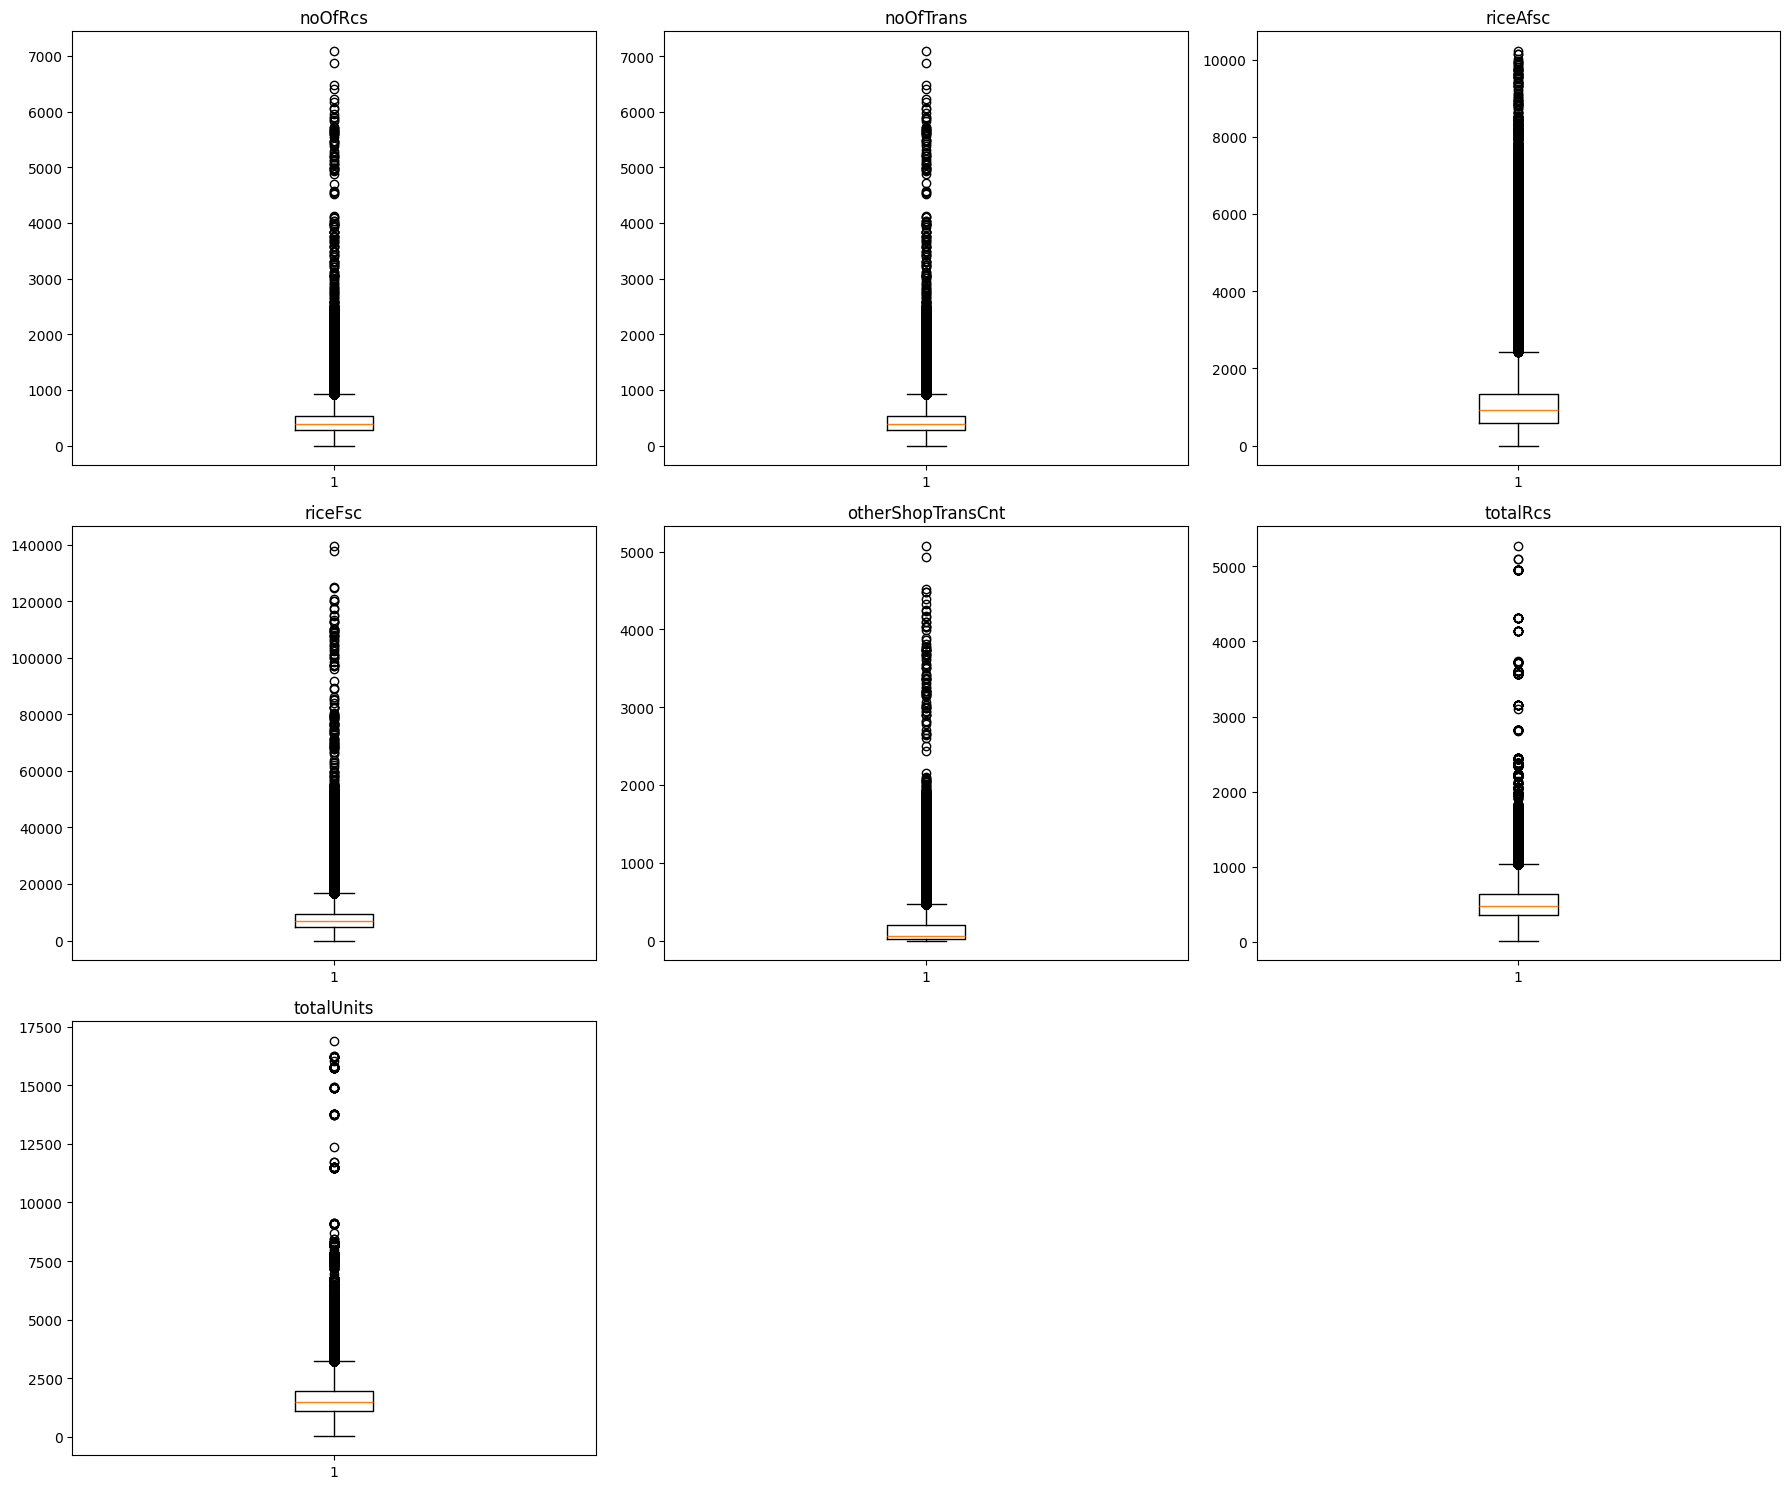

In [22]:
import matplotlib.pyplot as plt
import math

cols = outlier_cols

n_cols = 3  # columns in grid
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))

axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f"{col}")

# extra empty plots hide करो
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [23]:
for col in outlier_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower_limit, upper_limit)

print("Outliers clipped successfully")

Outliers clipped successfully


In [24]:
print("After Outliers Capped  :", df.shape)

After Outliers Capped  : (482257, 26)


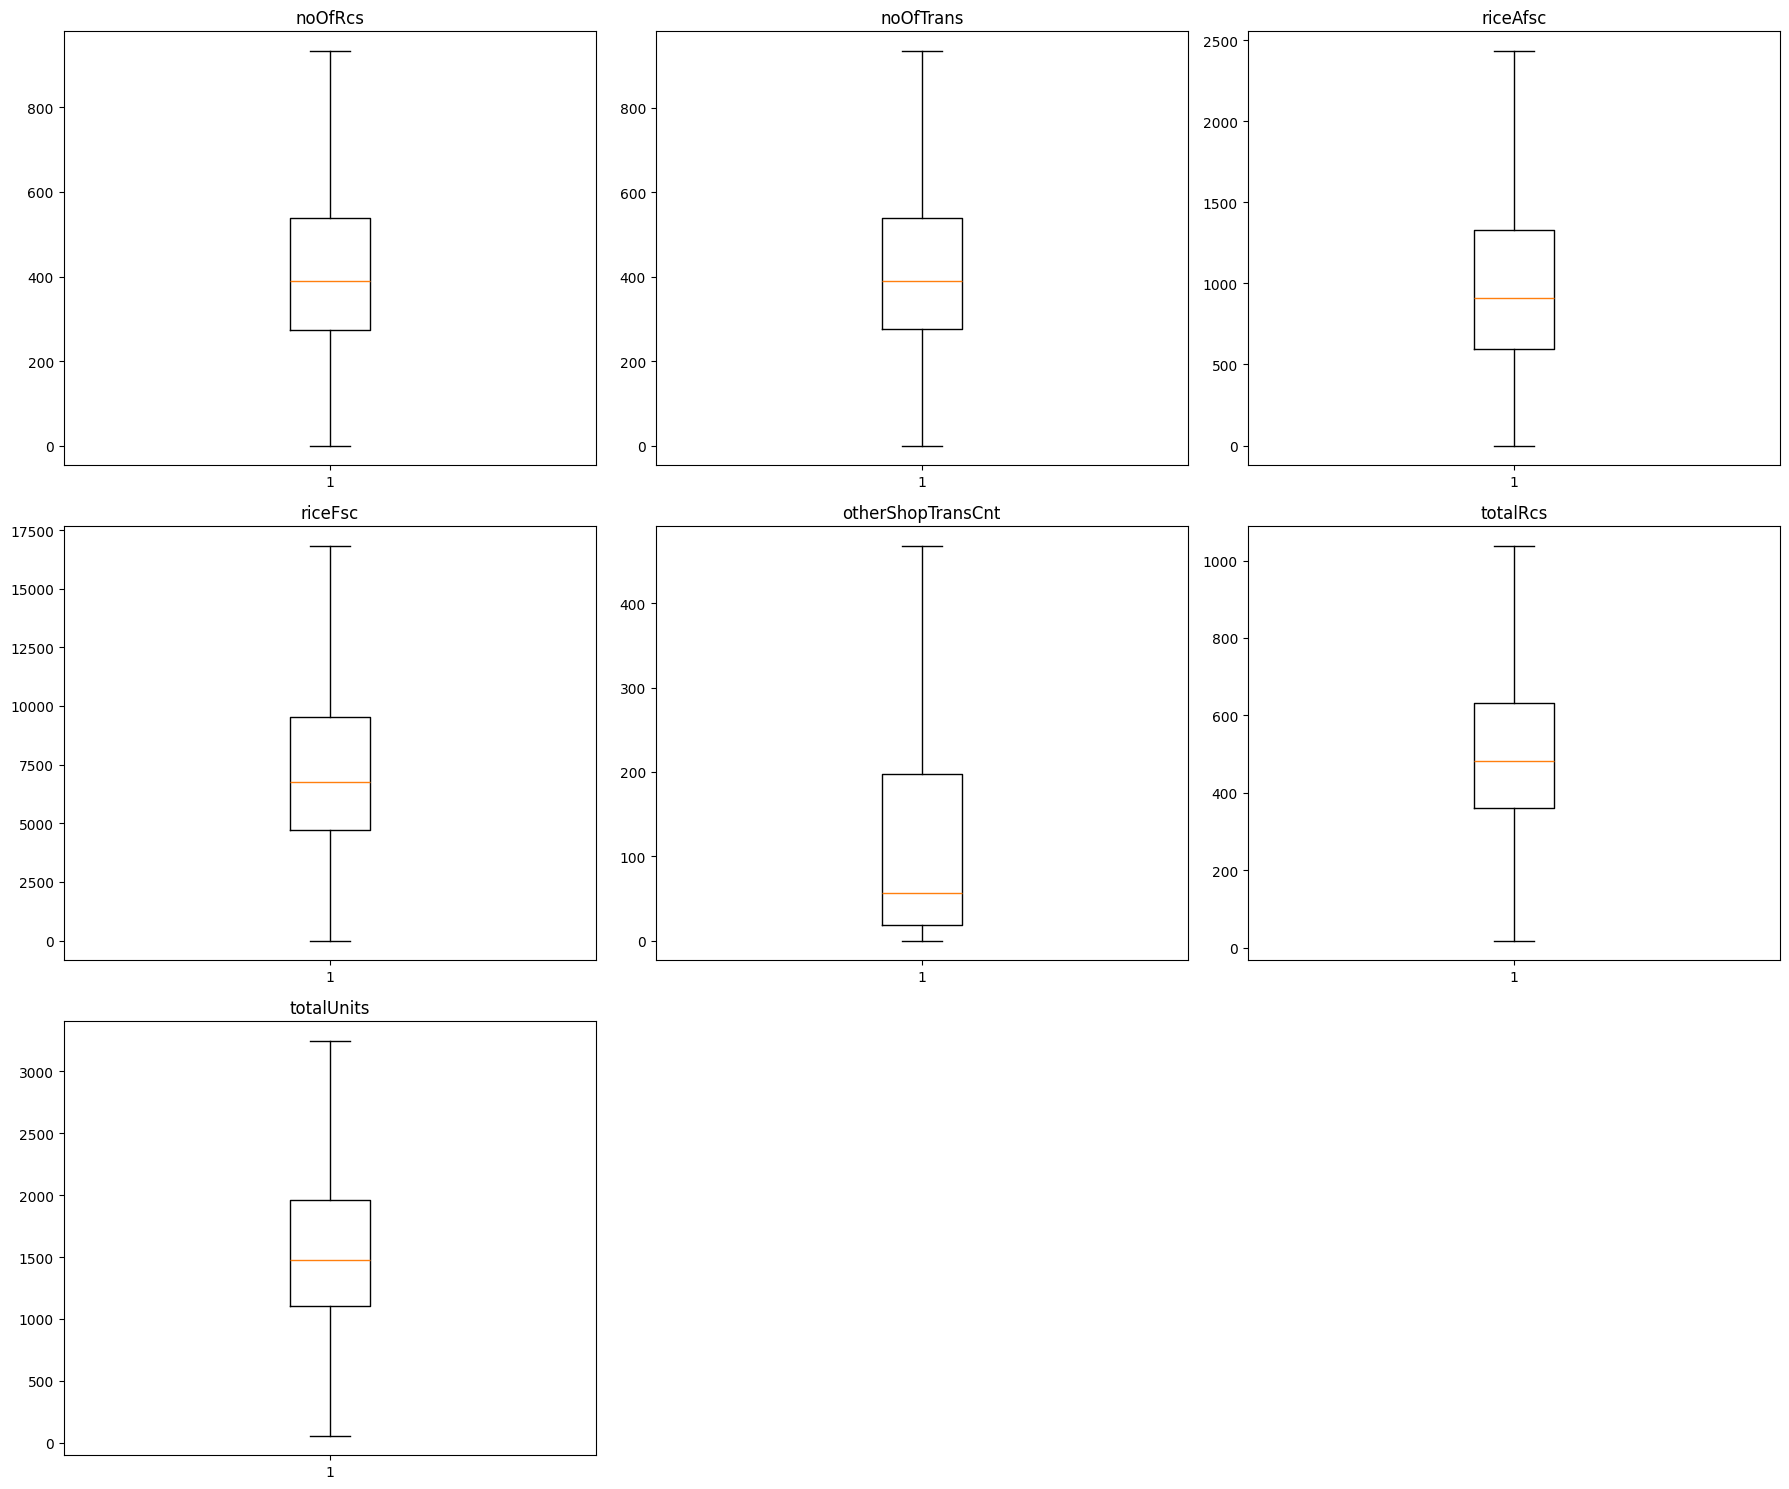

In [25]:
import matplotlib.pyplot as plt
import math

cols = outlier_cols

n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(cols):

    plt.subplot(n_rows, n_cols, i + 1)
    plt.boxplot(df[col].dropna())
    plt.title(col)

plt.tight_layout()
plt.show()

In [26]:
print(df.describe())

             shopNo          month           year        noOfRcs  \
count  4.822570e+05  482257.000000  482257.000000  482257.000000   
mean   2.920896e+06       5.750405    2023.750712     427.634256   
std    9.345536e+05       3.429293       0.738044     212.325150   
min    1.407001e+06       1.000000    2023.000000       1.000000   
25%    2.109033e+06       3.000000    2023.000000     275.000000   
50%    2.912003e+06       5.000000    2024.000000     390.000000   
75%    3.723021e+06       9.000000    2024.000000     538.000000   
max    4.612012e+06      12.000000    2025.000000     932.500000   

           noOfTrans       riceAfsc        riceFsc        riceAap  \
count  482257.000000  482257.000000  482257.000000  482257.000000   
mean      428.677732    1021.812163    7572.626733       2.073965   
std       212.749616     600.623478    3990.317736      11.929676   
min         1.000000       0.000000       0.000000       0.000000   
25%       276.000000     595.000000    470

In [27]:
df.to_csv("../data/Master_data/outlier_cliping_dataset.csv", index=False)

print("Final dataset saved")

Final dataset saved


In [28]:
df.columns

Index(['shopNo', 'month', 'year', 'noOfRcs', 'noOfTrans', 'riceAfsc',
       'riceFsc', 'riceAap', 'wheat', 'sugar', 'totalAmount',
       'otherShopTransCnt', 'riceAap_available', 'wheat_available', 'totalRcs',
       'totalUnits', 'units', 'distCode', 'distName', 'officeCode',
       'officeName', 'longitude', 'latitude', 'fpsStatus', 'fpsType',
       'dateTime'],
      dtype='object')

In [29]:
df.shape

(482257, 26)